In [1]:
# # remember to resteart kernell
# ! pip install -e ../../wazeasy
# ! pip install pandas "dask[complete]" pyarrow plotly
# ! pip install --upgrade s3fs
# ! pip install geopandas
# ! pip install seaborn
# ! pip install folium matplotlib mapclassifys
# ! pip install h3
# ! pip install dask-geopandas
# ! pip install folium matplotlib mapclassify

In [1]:
import pandas as pd
import dask.dataframe as dd
from wazeasy import utils, plots, reports
import geopandas as gpd
from shapely import Polygon
from h3 import LatLngPoly
import yaml

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [3]:
storage_options = {'profile': 'ddp'}
path = 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams*.parquet'
ddf = dd.read_parquet(path, storage_options = storage_options, engine = 'pyarrow')

In [4]:
timezone = config['Baghdad']['timezone']['timezone_name']
geographies = config['Baghdad']['geographies']

In [5]:
dict_geogs = {geog: gpd.read_file(geog_data['path']) for geog, geog_data in geographies.items()}

In [ ]:
utils.handle_time(ddf, timezone)
ddf = utils.assign_geography_to_jams(ddf, dict_geogs)
ddf = utils.remove_level5(ddf)

In [ ]:
reports.run_basic_report(ddf)

In [ ]:
reports.run_geog_report(ddf, geographies, start_date = None, end_date = None)

# Basic Analysis

In [9]:
plots.plot_year_to_year_tci(ddf, 'length')

alt.Chart(...)

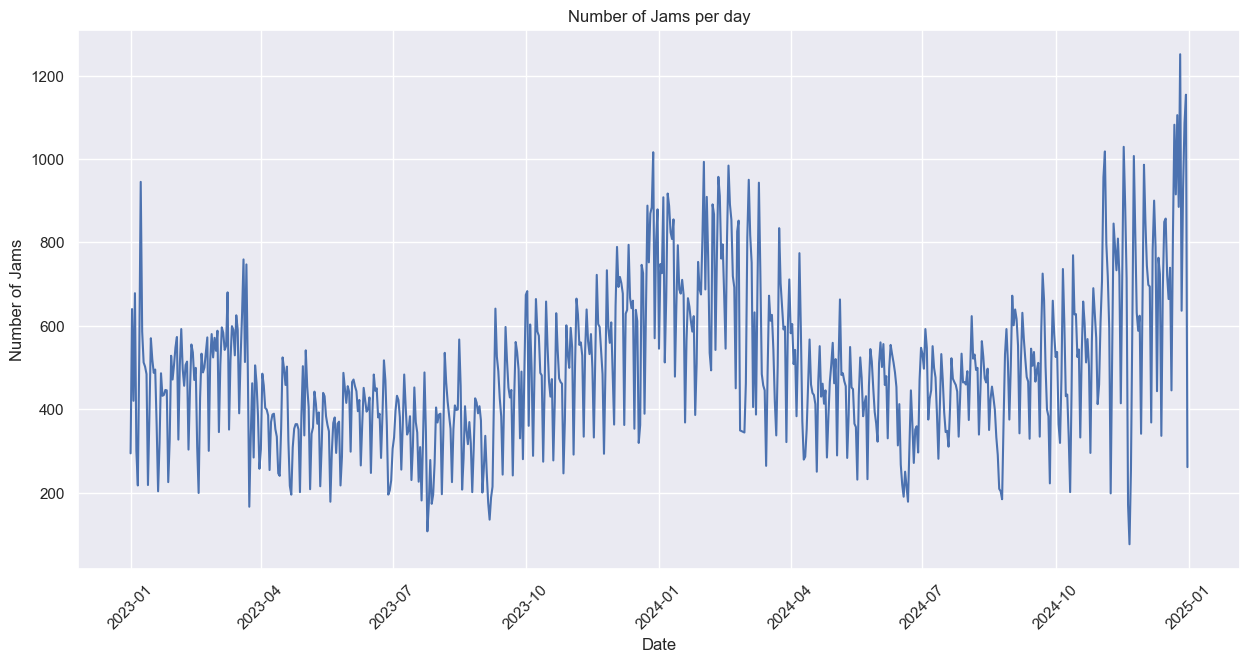

In [9]:
plots.jams_per_day(ddf)

In [10]:
plots.jams_per_day_altair(ddf, save_fig=False)

alt.Chart(...)

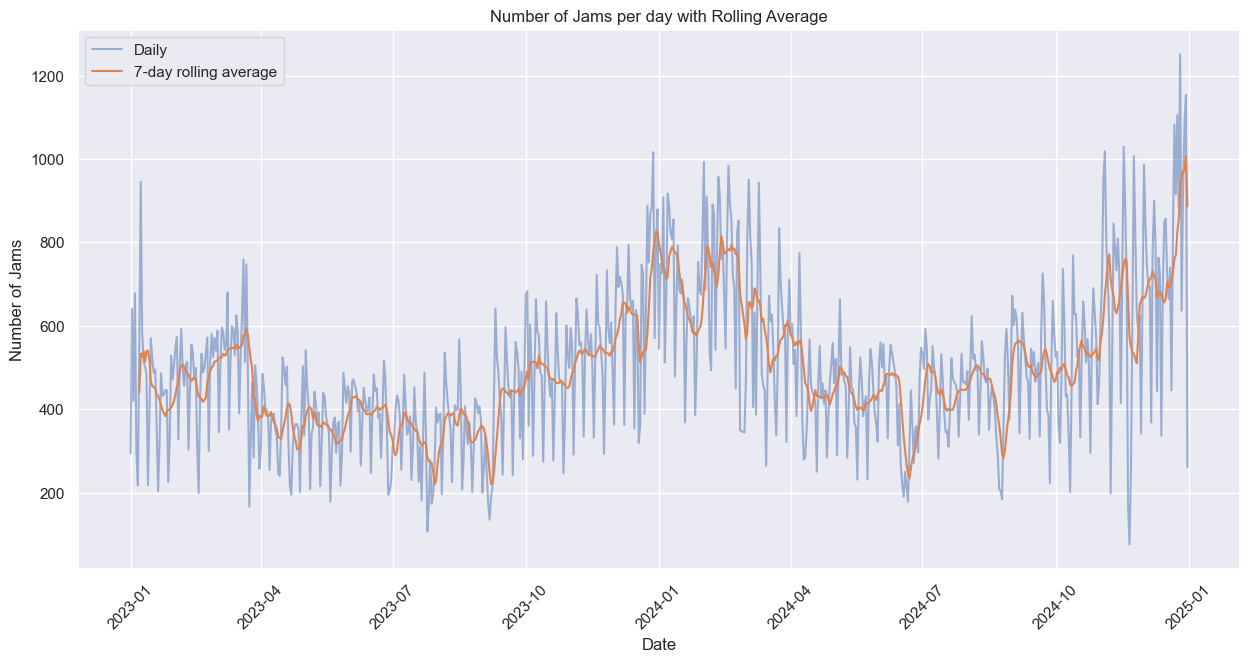

In [11]:
plots.jams_per_day_rolling_avg(ddf, window=7, save_fig=False)

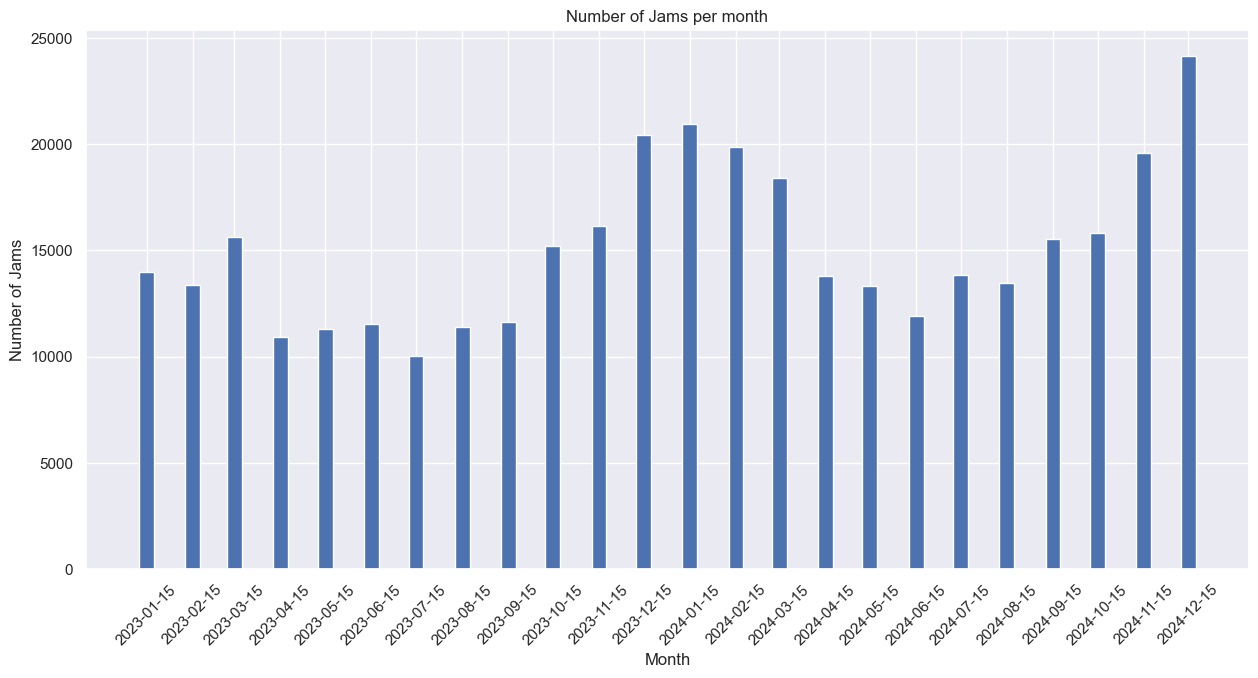

In [12]:
plots.jams_monthly_aggregated(ddf, save_fig = False)

In [8]:
plots.jams_per_day_per_level(ddf, save_fig=False)

alt.Chart(...)

In [10]:
plots.hourly_tci_by_month(ddf, dow = [1,2,3], group_name = 'Mon-Tue-Wed')

alt.Chart(...)

In [8]:
plots.map_tci(ddf, 'admin2', 'length', admin2, start_date = None, end_date = None, dow = None)

In [10]:
plots.map_tci(ddf, 'hex_id_7', 'length', hex_gdf, start_date = None, end_date = None, dow = None)

# Plots for different geography levels

In [9]:
plots.plot_tci_by_period_geography(ddf, ['date'], ['admin1'], 'length', custom_dates = None, save_fig = False)

alt.Chart(...)

In [10]:
plots.plot_tci_by_period_geography(ddf, ['date'], ['admin2'], 'length', custom_dates = None, save_fig = False)

alt.Chart(...)

In [11]:
plots.plot_tci_by_period_geography(ddf, ['date'], ['region'], 'length', custom_dates = None, save_fig = False)

alt.Chart(...)

In [9]:
start_date = '2023-01-01'
end_date = '2023-12-31'
dow = [1,2,3]
agg_spatial = 'admin2'
agg_column = 'length'
group_name = 'Mon-Tue-Wed'

plots.hourly_tci_by_geog(ddf, agg_spatial, agg_column, group_name, start_date = start_date, end_date = end_date, dow = dow)

alt.Chart(...)

# Accidents